In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Create the Taxi environment with text (ANSI) rendering
env = gym.make("Taxi-v3", render_mode="ansi")

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)


Number of states: 500
Number of actions: 6


In [2]:
def reset_env(env):
    """
    Reset environment and return only the observation (state id).
    """
    obs, info = env.reset()
    return obs

def step_env(env, action):
    """
    Take one step in the environment.
    Unifies Gymnasium's (obs, reward, terminated, truncated, info)
    into (obs, reward, done, info).
    """
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    return obs, reward, done, info

def render_env(env):
    """
    Print the ASCII grid of the Taxi environment.
    """
    print(env.render())


In [3]:
action_meaning = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pickup",
    5: "Dropoff",
}

for a in range(env.action_space.n):
    print(a, "-", action_meaning[a])


0 → South
1 → North
2 → East
3 → West
4 → Pickup
5 → Dropoff


In [4]:
# Q-Learning Table and Hyperparameters

# State and action space sizes
state_space_size  = env.observation_space.n   # 500
action_space_size = env.action_space.n        # 6

# Q-table: one row per state, one column per action
# Q[s, a] = estimated value of taking action a in state s
Q_init = np.zeros((state_space_size, action_space_size))
print("Initial Q-table shape:", Q_init.shape)

# Hyperparameters for Q-learning
alpha = 0.1     # learning rate
gamma = 0.99    # discount factor

epsilon_start = 1.0    # initial exploration rate
min_epsilon   = 0.01   # minimum exploration
epsilon_decay_A = 0.995  # epsilon decay rate for this basic model (Model A)

num_episodes = 5000    # training episodes
max_steps    = 200     # max steps per episode


Initial Q-table shape: (500, 6)


In [ ]:
# Q-Learning Training Function

def train_q_learning(env,
                     num_episodes=5000,
                     max_steps=200,
                     alpha=0.1,
                     gamma=0.99,
                     epsilon_start=1.0,
                     epsilon_decay=0.995,
                     min_epsilon=0.01):
    """
    Train a Q-learning agent on Taxi-v3.

    Returns:
      Q       - learned Q-table (numpy array)
      rewards - list of total reward per episode
    """
    state_space_size  = env.observation_space.n
    action_space_size = env.action_space.n

    # Start with all zeros
    Q = np.zeros((state_space_size, action_space_size))
    epsilon = epsilon_start
    rewards = []

    for ep in range(num_episodes):
        state = reset_env(env)
        done = False
        total_reward = 0

        for step in range(max_steps):
            # ε-greedy action selection
            if np.random.rand() < epsilon:
                action = env.action_space.sample()  # explore
            else:
                action = np.argmax(Q[state])        # exploit

            next_state, reward, done, info = step_env(env, action)

            # Q-learning update
            old_value = Q[state, action]
            next_max  = np.max(Q[next_state])

            target = reward + gamma * next_max
            Q[state, action] = old_value + alpha * (target - old_value)

            state = next_state
            total_reward += reward

            if done:
                break

        # decay epsilon after each episode
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        rewards.append(total_reward)

        # Progress log every 500 episodes
        if (ep + 1) % 500 == 0:
            print(
                f"Episode {ep+1}/{num_episodes} | "
                f"Total reward: {total_reward} | "
                f"Epsilon: {epsilon:.3f}"
            )

    return Q, rewards


Episode 500/5000 | Total reward: -132 | Epsilon: 0.082
Episode 1000/5000 | Total reward: 10 | Epsilon: 0.010
Episode 1500/5000 | Total reward: 5 | Epsilon: 0.010
Episode 2000/5000 | Total reward: 10 | Epsilon: 0.010
Episode 2500/5000 | Total reward: 8 | Epsilon: 0.010
Episode 3000/5000 | Total reward: 11 | Epsilon: 0.010
Episode 3500/5000 | Total reward: 7 | Epsilon: 0.010
Episode 4000/5000 | Total reward: 8 | Epsilon: 0.010
Episode 4500/5000 | Total reward: 5 | Epsilon: 0.010
Episode 5000/5000 | Total reward: 6 | Epsilon: 0.010
Model A - average reward over last 100 episodes: 7.62


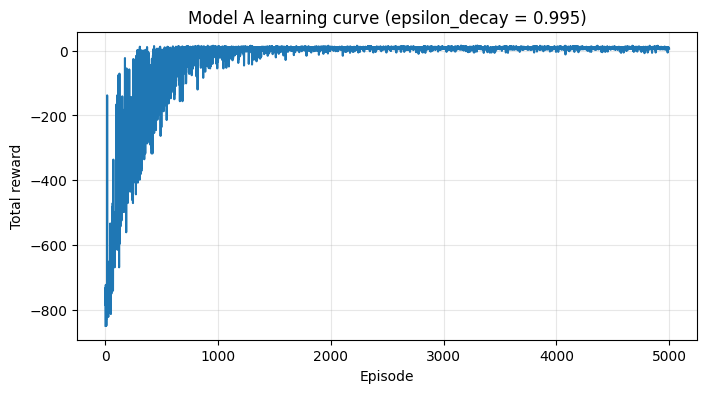

In [36]:
# Training

Q_A, rewards_A = train_q_learning(
    env,
    num_episodes=num_episodes,
    max_steps=max_steps,
    alpha=alpha,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_decay=epsilon_decay_A,
    min_epsilon=min_epsilon,
)

print("Model A - average reward over last 100 episodes:",
      np.mean(rewards_A[-100:]))

plt.figure(figsize=(8, 4))
plt.plot(rewards_A)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Model A learning curve (epsilon_decay = 0.995)")
plt.grid(True, alpha=0.3)
plt.show()


In [7]:
# Evaluation Function

def evaluate_agent(env, Q, episodes=100, max_steps=200):
    """
    Evaluate a trained Q-table by always taking the greedy action.
    Returns:
      rewards    - list of total rewards per episode
      steps_list - list of steps taken per episode
    """
    rewards = []
    steps_list = []

    for ep in range(episodes):
        state = reset_env(env)
        done = False
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            action = np.argmax(Q[state])  # always take best action
            state, reward, done, info = step_env(env, action)
            total_reward += reward
            steps += 1

            if done:
                break

        rewards.append(total_reward)
        steps_list.append(steps)

    return rewards, steps_list


In [34]:
# Evaluating Model A

greedy_rewards_A, greedy_steps_A = evaluate_agent(env, Q_A, episodes=3000, max_steps=500)

print("Model A (greedy policy) - average reward over 3000 episodes:",
      np.mean(greedy_rewards_A))
print("Model A (greedy policy) - best reward over 3000 episodes:",
      np.max(greedy_rewards_A))
print("Model A (greedy policy) - worst reward over 3000 episodes:",
      np.min(greedy_rewards_A))
print("Model A (greedy policy) - average steps per episode:",
      np.mean(greedy_steps_A))


Model A (greedy policy) - average reward over 3000 episodes: 8.004333333333333
Model A (greedy policy) - best reward over 3000 episodes: 15
Model A (greedy policy) - worst reward over 3000 episodes: 3
Model A (greedy policy) - average steps per episode: 12.995666666666667


In [9]:
# Visually watching 1 greedy episode

state = reset_env(env)
render_env(env)
done = False
total_reward = 0
step_count = 0

print("\nGreedy run with Model A:\n")

while not done and step_count < 30:
    action = np.argmax(Q_A[state])
    print(f"Step {step_count+1}, action {action} ({action_meaning[action]})")
    state, reward, done, info = step_env(env, action)
    total_reward += reward
    render_env(env)
    print("Reward:", reward, "\n")
    step_count += 1

print("Episode finished. Total reward:", total_reward)
print("Steps taken:", step_count)


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



Greedy run with Model A:

Step 1, action 2 (East)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

Reward: -1 

Step 2, action 2 (East)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

Reward: -1 

Step 3, action 2 (East)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

Reward: -1 

Step 4, action 0 (South)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Reward: -1 

Step 5, action 0 (South)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Reward: -1 

Step 6, action 4 (Pickup)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

Reward: -1 

Step 7, action 1 (North)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : |_: |
|Y| : |B